<a href="https://colab.research.google.com/github/flaviocorrea-usa/Repo_FlavioCorrea/blob/main/Project_FlavioCorrea_2026Apr09_1137PM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="font-size:16px; background-color: lightblue;border: 2px solid gray;"> <img src="https://dce.harvard.edu/wp-content/uploads/2025/01/DCE-50th-Anniversary-Social-Media-Profile-Photo-Crimson.png" width="80" alt="image info" align="right" />

# PROJECT PROPOSAL - Fraud Detection
## CSCI E-25 - Computer Vision - Spring Term 2026
## Professor: Steve Elston

### Author: Flavio C C Correa  

_This project proposal is part of the Graduate Credit Requirements towards ALM Data Science, to which the author is a candidate_

_____________________________________

## 1 - Introduction

### 1.1 - Purpose and Objective

Banking and Financial institutions are the backbone of the world economy today. The global economy flows through the different channels that banks set up for the moviment of money, support the enormous moviment of merchandise and services.

One key element that is important and impacts the flow of goods and services is the fraud that can be an economic burden to the interemediate part in the transactions, which can increase the risk of transactions, and therefore the cost of the capital for the economy.

In a recent study, it was found that the impact of fraud extends beyond direct monetary costs. Severe tail fraud events lead banks to significantly reduce loan growth, with effects more pronounced at institutions with weaker capital and liquidity positions (Curti & Mihov, 2025).

Therefore, this project aims at creating an image fraud detector of images used in banking transactions, especially focused on documentation used to open accounts and generate transactions (e.g., government issue IDs, passports, etc.).

The objective is to genreate the fraud detector can be at least able to provide a probability of document being a fraud to be used as a reference by banks' internal fraud and KYC (Know Your Customer) units to stop transactions and prevent impact to their transactions.
__________



### 1.2 - Dataset

#### 1.2.1 - Difficulties with similar datasets

Government issued IDs are not easy to get in datasets. Questions linked to identity theft, regulations like the Federal Trade Commission Title 16, Part 681, prevent that images that could be used to steal identity of actual persons can be publicly available in open databases in the internet.

The solution is to use a Sybtheic dataset of ID and Travel Documents.

Luckily, there is a dataset that was created with the sole puporse of training and evaluating forged ID documents detection systems.



#### 1.2.2 - Dataset used in this project

According to the abstract of the paper Boned C, et all (2024), it is difficult to collect data from real world. Therefore, for the purposes similar to the scope of this project, they generated a synthetic dataset called STDTD (Synthetic dataset of ID and Travel Documents). In the authors words:

"The SIDTD dataset is created to help training and evaluating forged ID documents detection systems. Such a dataset has become a necessity as ID documents contain personal information and a public dataset of real documents can not be released. Moreover, forged documents are scarce, compared to legit ones, and the way they are generated varies from one fraudster to another resulting in a class of high intra-variability." Boned C, et all (2024)



#### 1.2.3 - Non-exhaustive List of Libraries

In quick analyzing some documentation and doing a search in the internet, I came with a list of libraries that need to be installed. As I need to start with some core packages, I will install the ones I believe are necessary.


##### Core libraries
- BigGAN pytorch-pretrained-biggan
- Torch, PyTorch, and TorchVision
- EfficientNet timm
- Grad Cam pytorch-grad-cam
- Augmentation albumentations
- Opencv-python

##### Supporting libraries
- OS
- Random
- Numpy
- Pandas
- Matplotlib.pyplot
- Seaborn
- tqdm

Please note that this list is not intended to be exhaustive. There must be (and most likely it will be) additional packages that may be missing, but these are at least the ones that seem to be the ones I might need to install.

________________________

## 2 - Model and Techniques

### 2.1 - Models and techniques

The idea is that the genration of fake images and forged documents using AI has been growing over the last years. Liu et all (2025) says that many different techniques, like "Variational Autoencoders (VAEs), generative adversarial networks (GANs), and diffusion models (DMs) are among the Deepfake generation models capable of synthesizing nonexistent faces by learning the data distribution of real-world human faces". Generating human faces is the most challenging task undertaken by fraudsters, therefore the task to create entire identification documents is surpassed by tese techniques.

The rapid development of new deepfakes that show seamless and near-perfect fabrications play a major role in the concerns of cybersecurity professionals of banks and financial institutions. Typical detectors (again according to Liu et al, 2025) usually frame detection as a binary classification.

As per what was discussed in class is that the best way is to crreate a discrimiative classifier to tackle this issue.


#### 2.1.1 - Generative Adversarial Networks - GANs

A GAN consists of two neural networks trained in competition to see which one minimizes teh minimax function. The Generator G learns a mapping from a noise vector to an image x = G(z), while the Discriminator D learns to distinguish real images $x \sim p_{data}$ from generated ones.

The idea is to train in a minimax fashion, using the following function:

![image.png](attachment:020c6aef-717f-44f6-905d-e0a86f3e8b02.png)

Source: Goodfellow et all, 2014

There are other slightly different variants that are important: PGAN and BigGAN. Progressive Gan may be a good alternative, as it increases progressively the semantic field from low resolution to high resolution, adding layers in between. Big GAN  is also a good variant, as it can deal with large batch sizes. I believe they can be a good help for the training steps, depending how detailed this needs to go.


#### 2.1.2 - Discriminative MOdels - Primary Discriminator

AS the primary discrimnator, Efficient Net appears to be a good model to focus on. Based on Tan et al (2020), it is an efficient way of improving accuracy and at the same time improving efficiency to resolve teh discriminating what it is. So, Tan et all scales three dimensions jointly using fized rations derived by a neural architecture. Using a scaling coeficient $\phi$, it is possible to scale depth, width and resolution, like in the image below:

![image.png](attachment:0697a85b-2038-451e-b35a-57ab8d2fca8b.png)

Source: Tan et al (2020)

The idea is to use the concept of multiple scaling on dimensions of the network with a fixed ratio.
![image.png](attachment:21e2b495-7f6e-4cde-b7af-a083577bdd52.png)
Source: Tan et al (2020)

Using $\phi$ = 2, like in the mentioned article, we might have a good level of resolution and can be used for identity documents classification, as some anomal;ies are captured there, like anomalies or subtleties in the images. The value of $\phi$ can be altered if the resolution is too coarse and it doesn't yield good results.

Additionally, computing it with pre-trained ImageNet, there is a good chance to have a decent discriminator.

________________________________

## 3. Comparative Models

The first idea is to use a Vision Transformer as the first comparison model. This is one of the simplest models we reviewed and it fits well as a comparative model.

The second one is ResNet-50, which is a fair model for comparison.

### 3.1 Vision Transformer

As mentioned in Dosovitskiy et al., 2020, the transformer encoder consists of alternating layers of multiheaded selfattention (MSA) and MLP blocks. According to this article, the transformer treats the image as a
sequence of patches and process it by a standard Transformer encoder as used in NLP. This simple
yet scalable, strategy works surprisingly well when coupled with pre-training on large dataset .
Thus, Vision Transformer matc on many image classificat on
datasets, whilst being relatively cheap to pre-tr

Considering this, we will use as a primary comparative model.ain.



### 3.2 ResNet-50

ResNet (He et al., 2016) introduced residual connections that allow gradients to flow through very deep networks without vanishing. Each residual block computes $y=\mathcal{F}(x,{Wi​})+x$, where $\mathcal{F}$ is a stack of convolutional layers.

In the context of this project, ResNet-50 serves as a reference. if Efficient Net and ViT outperform it, that validates the suitability of those models.

__________________________________

## 4. Project Plan

### 4.1 - Initial Project Plan

I divided this project in Phases to make it more common sensical to anyone checking it from outside of my head:

#### PHASE I - Data download and pre-analysis:
1. Package Installation & Imports
2. Data Download & Extraction (SIDTD)
3. Exploratory Data Analysis (EDA)

This initial phase will take care of preparing the terrain for the project. I will download the packages already identified and will include here the additional packages as I progress in the coding. Then, I will download and extract the mentioned dataset (SIDTD) and do a initial exploratory analysis. This will be simple analysis, like bar charts with the classes, some examples of fake vs real images, and some additional statistics, like histograms and mean or standard deviation information.

#### PHASE II - Preprocessing:
4. Preprocessing Pipeline
5. Augmentation analysis
6. Train/Validation/Test Split
7. Model Definition (EfficientNet / VIT / ResNet)

This will provide me with the preprocessing I need to move forward witht he project. The idea is to review the need of augmentation to increase thenumber of options for training, break down the data set in train, validation and testing subsets, and have the models defined here.

#### PHASE III - Training and inference:
8. Training loop with at least 50 epochs.
9. Probabilistic inference of the validation set

This Phase will require a good amount of computation, therefore this is the part that will require a Google Colab intervention. Running the trainings will be the main weight part, and I will be user transfer learning to ensure this takes less time by using previsouly defined weights. My initial thought is ImageNet to do this transfer learning.

#### PHASE IV - Final Assessment - Analysis and Metrics
10. Metrics & Visualizations (Loss curves, ROC, Confusion Matrix, Grad-CAM)
11. Error Analysis
12. Summary and Conclusion

This will give me the full project a structure that I need to move forward with achieving the goal of creating the discrimantor and the classifier of fake vs document ID images



_________________________

### 4.2 - Initial Analysis of data

Reviewing the data, I start by installing the packages and importing the data.

I also setup some items for future items already, like project path in my folder.

#### 4.1.1 - PHASE I - Step 1: Package Installation and Imports

In [1]:
# ============================================================
# PHASE I - Step 1: Package Installation and Imports
# ============================================================

import os
import io
import zipfile
import json
import random
import shutil
import requests
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Project folders
PROJECT_ROOT = Path.cwd() / "sidtd_project"
RAW_DIR = PROJECT_ROOT / "raw"
EXTRACTED_DIR = PROJECT_ROOT / "extracted"
SPLITS_DIR = PROJECT_ROOT / "splits"

for d in [PROJECT_ROOT, RAW_DIR, EXTRACTED_DIR, SPLITS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data dir:", RAW_DIR)
print("Extracted data dir:", EXTRACTED_DIR)
print("Splits dir:", SPLITS_DIR)
print("Imports successful.")


Project root: /content/sidtd_project
Raw data dir: /content/sidtd_project/raw
Extracted data dir: /content/sidtd_project/extracted
Splits dir: /content/sidtd_project/splits
Imports successful.


#### 4.1.2 - PHASE I - Step 2: Data Download & Extraction (SIDTD)

In [2]:
# ============================================================
# PHASE I - STEP 2: Data Download & Extraction (SIDTD)
# ============================================================

from pathlib import Path

# Official SIDTD Dataverse file IDs observed on the public file pages
# templates.zip  -> fileId=133935
# hold_out_split.zip -> fileId=134164
BASE_API = "https://dataverse.csuc.cat/api/access/datafile"

FILES = {
    "templates.zip": f"{BASE_API}/133935",
    "hold_out_split.zip": f"{BASE_API}/134164",
}

def download_file(url: str, destination: Path, chunk_size: int = 1024 * 1024):
    """Download a file with streaming and progress bar."""
    if destination.exists() and destination.stat().st_size > 0:
        print(f"✓ Already exists: {destination.name}")
        return

    print(f"Downloading {destination.name} ...")
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(destination, "wb") as f, tqdm(
            total=total, unit="B", unit_scale=True, unit_divisor=1024
        ) as pbar:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
    print(f"✓ Downloaded: {destination}")

def extract_zip(zip_path: Path, extract_to: Path):
    """Extract zip file only if destination does not already contain files."""
    extract_to.mkdir(parents=True, exist_ok=True)
    existing_files = list(extract_to.rglob("*"))
    if len(existing_files) > 0:
        print(f"✓ Already extracted: {extract_to}")
        return

    print(f"Extracting {zip_path.name} -> {extract_to} ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_to)
    print(f"✓ Extracted to: {extract_to}")

# Download
for filename, url in FILES.items():
    download_file(url, RAW_DIR / filename)

# Extract
extract_zip(RAW_DIR / "templates.zip", EXTRACTED_DIR / "templates")
extract_zip(RAW_DIR / "hold_out_split.zip", SPLITS_DIR / "hold_out")

# Quick sanity check: print a short folder tree
def print_tree(root: Path, max_depth: int = 3, max_entries: int = 8):
    root = Path(root)
    print(f"\nFolder tree for: {root}")
    for path in sorted(root.rglob("*")):
        rel = path.relative_to(root)
        depth = len(rel.parts)
        if depth > max_depth:
            continue
        indent = "    " * (depth - 1)
        print(f"{indent}- {rel.name}")
        max_entries -= 1
        if max_entries <= 0:
            print("    ...")
            break

print_tree(EXTRACTED_DIR / "templates", max_depth=3, max_entries=25)
print_tree(SPLITS_DIR / "hold_out", max_depth=3, max_entries=25)

  0%|          | 0.00/1.19G [00:00<?, ?B/s]

✓ Downloaded: /content/sidtd_project/raw/templates.zip


  0%|          | 0.00/20.7k [00:00<?, ?B/s]

✓ Downloaded: /content/sidtd_project/raw/hold_out_split.zip
Extracting templates.zip -> /content/sidtd_project/extracted/templates ...
✓ Extracted to: /content/sidtd_project/extracted/templates
Extracting hold_out_split.zip -> /content/sidtd_project/splits/hold_out ...
✓ Extracted to: /content/sidtd_project/splits/hold_out

Folder tree for: /content/sidtd_project/extracted/templates
- templates
    - Annotations
        - fakes
        - reals
    - Images
        - fakes
        - reals

Folder tree for: /content/sidtd_project/splits/hold_out
- split_normal
    - test_split_SIDTD.csv
    - train_split_SIDTD.csv
    - val_split_SIDTD.csv


#### 4.1.3 - PHASE I - STEP 3: Exploratory Data Analysis (EDA)

Found 2,222 image files
Found 3 CSV split files


Reading sampled images:   0%|          | 0/1000 [00:00<?, ?it/s]


Sampled image metadata:


,filepath,filename,suffix,label_guess,width,height,aspect_ratio,mean_pixel,std_pixel,filesize_kb
0,/content/sidtd_project/extracted/templates/tem...,est_id_11_fake_9_83.jpg,.jpg,fake,929,580,1.6017,201.836349,53.007141,71.44
1,/content/sidtd_project/extracted/templates/tem...,rus_internalpassport_03.jpg,.jpg,real,1519,1069,1.4210,212.639856,37.753164,462.28
2,/content/sidtd_project/extracted/templates/tem...,rus_internalpassport_94_fake_1_97.jpg,.jpg,fake,1519,1069,1.4210,211.799774,42.981678,201.41
3,/content/sidtd_project/extracted/templates/tem...,est_id_92.jpg,.jpg,real,929,580,1.6017,205.042480,46.819866,201.21
4,/content/sidtd_project/extracted/templates/tem...,alb_id_10_fake_6_67.jpg,.jpg,fake,2167,1360,1.5934,191.647294,49.729018,707.36



Basic summary:


...

Columns: ['label_name', 'label', 'image_path', 'class', 'class_name']

CSV: train_split_SIDTD.csv | shape=(2511, 5)


,label_name,label,image_path,class,class_name
0,reals,0,templates/Images/reals/fin_id_11.jpg,4,fin
1,fakes,1,templates/Images/fakes/aze_passport_57_fake_9_...,1,aze
2,reals,0,templates/Images/reals/rus_internalpassport_37...,7,rus
3,fakes,1,templates/Images/fakes/srb_passport_69_fake_2_...,8,srb
4,fakes,1,templates/Images/fakes/grc_passport_49_fake_8_...,5,grc


Columns: ['label_name', 'label', 'image_path', 'class', 'class_name']

CSV: val_split_SIDTD.csv | shape=(313, 5)


,label_name,label,image_path,class,class_name
0,reals,0,templates/Images/reals/aze_passport_02.jpg,1,aze
1,fakes,1,templates/Images/fakes/esp_id_37_fake_7_99.jpg,2,esp
2,reals,0,templates/Images/reals/alb_id_66.jpg,0,alb
3,fakes,1,templates/Images/fakes/aze_passport_54_fake_9_...,1,aze
4,fakes,1,templates/Images/fakes/rus_internalpassport_66...,7,rus


Columns: ['label_name', 'label', 'image_path', 'class', 'class_name']


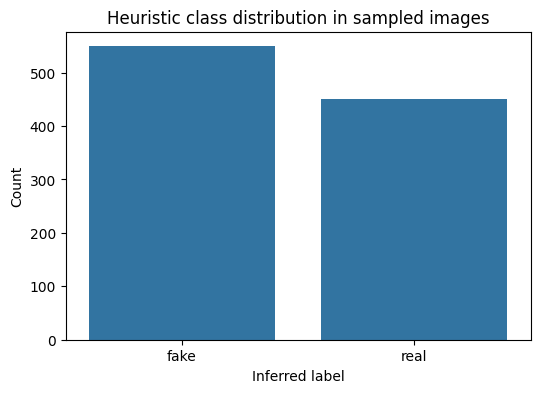

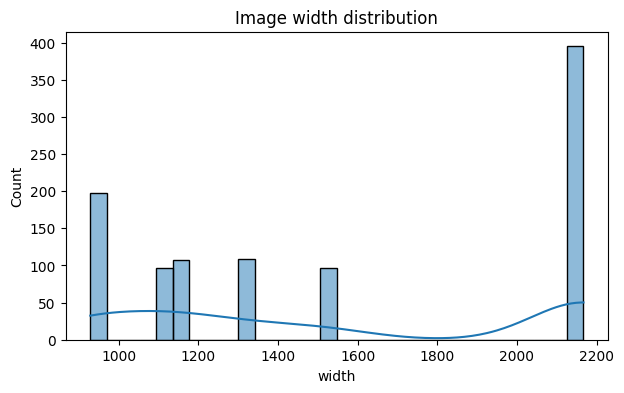

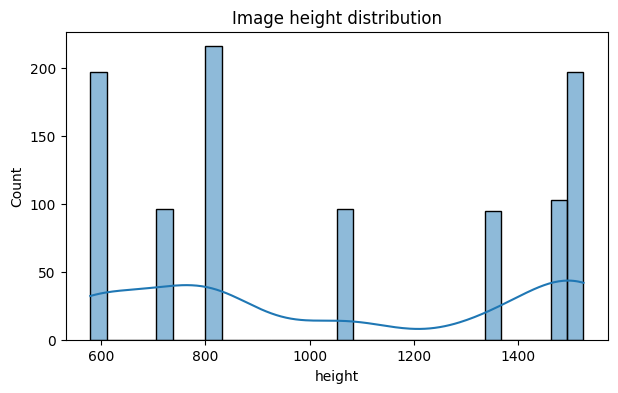

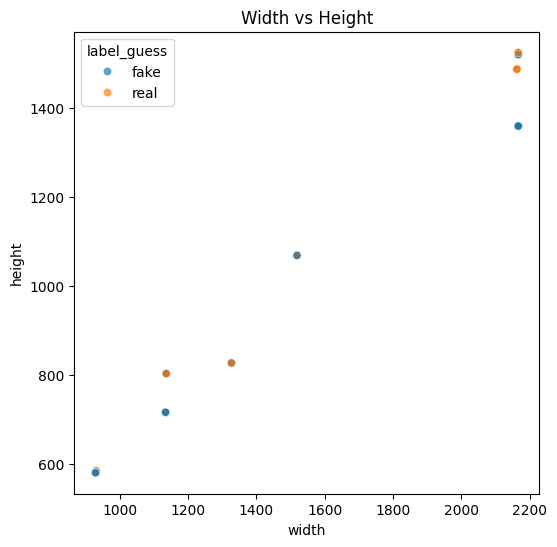

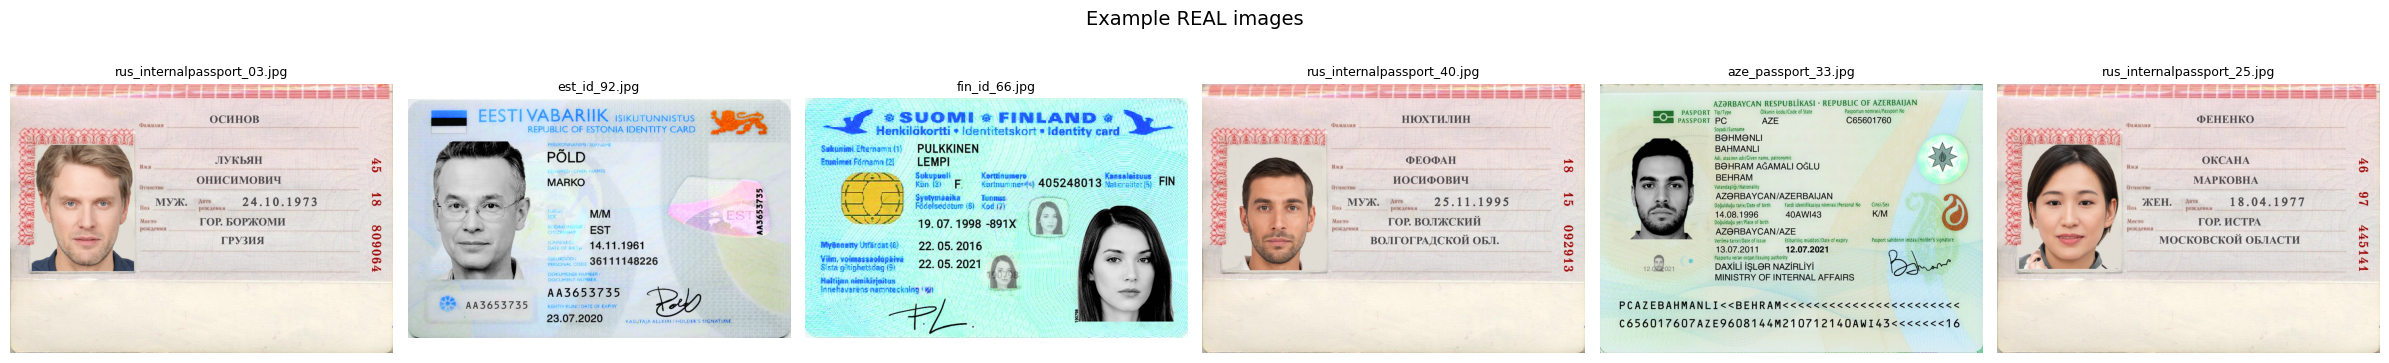

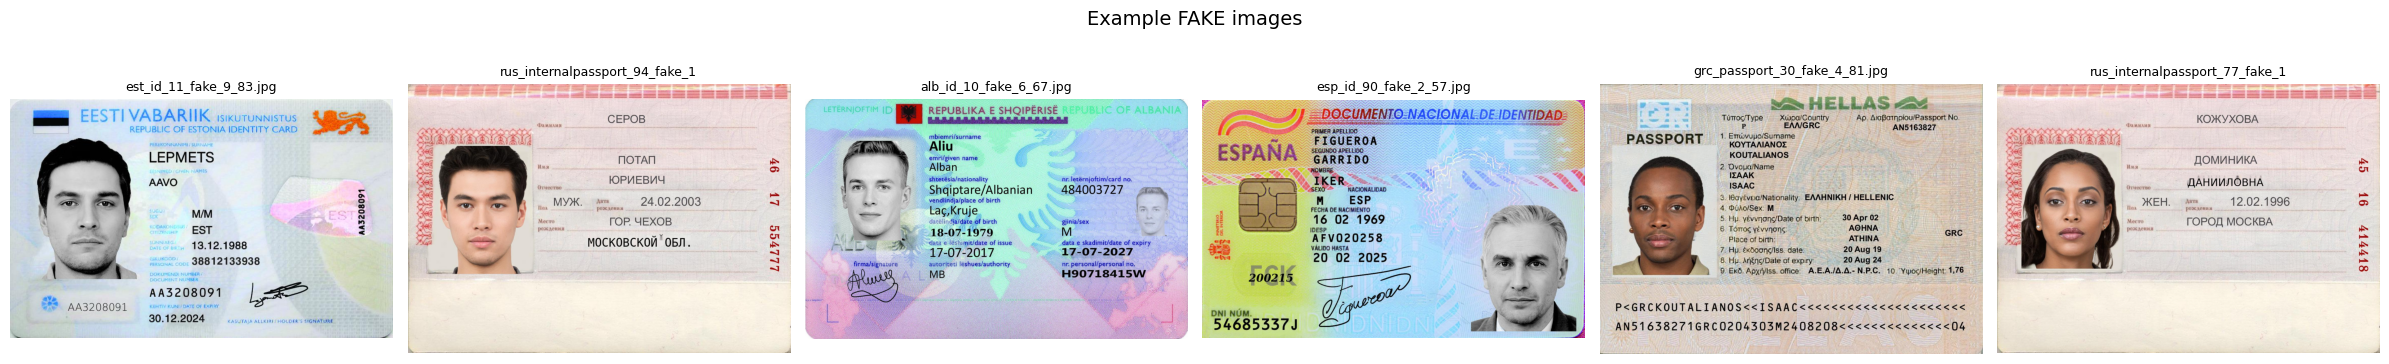

No examples found for: Example UNKNOWN-label images

Top folders containing images:


,folder_name,count
0,fakes,1222
1,reals,1000



EDA complete.


In [3]:
# ============================================================
# PHASE I - STEP 3: Exploratory Data Analysis (EDA)
# ============================================================

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

templates_root = EXTRACTED_DIR / "templates"
holdout_root = SPLITS_DIR / "hold_out"

image_paths = sorted([p for p in templates_root.rglob("*") if p.suffix.lower() in IMAGE_EXTS])
csv_paths = sorted(list(holdout_root.rglob("*.csv")))

print(f"Found {len(image_paths):,} image files")
print(f"Found {len(csv_paths)} CSV split files")

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def infer_label_from_path(path: Path):
    """Heuristic label extraction from file path."""
    s = str(path).lower()

    real_keywords = ["real", "genuine", "bonafide", "bona_fide", "authentic"]
    fake_keywords = ["fake", "forg", "forged", "fraud", "synthetic", "attack", "spoof"]

    for kw in real_keywords:
        if kw in s:
            return "real"
    for kw in fake_keywords:
        if kw in s:
            return "fake"
    return "unknown"

def safe_open_image(path: Path):
    try:
        with Image.open(path) as img:
            arr = np.array(img.convert("RGB"))
            return arr
    except Exception:
        return None

def summarize_image(path: Path):
    arr = safe_open_image(path)
    if arr is None:
        return None
    h, w = arr.shape[:2]
    return {
        "filepath": str(path),
        "filename": path.name,
        "suffix": path.suffix.lower(),
        "label_guess": infer_label_from_path(path),
        "width": w,
        "height": h,
        "aspect_ratio": round(w / h, 4) if h > 0 else np.nan,
        "mean_pixel": float(arr.mean()),
        "std_pixel": float(arr.std()),
        "filesize_kb": round(path.stat().st_size / 1024, 2),
    }

# ------------------------------------------------------------
# Build metadata table
# ------------------------------------------------------------
sample_size = min(1000, len(image_paths))   # keep Phase I lightweight
sample_paths = random.sample(image_paths, sample_size) if image_paths else []

records = []
for p in tqdm(sample_paths, desc="Reading sampled images"):
    rec = summarize_image(p)
    if rec is not None:
        records.append(rec)

eda_df = pd.DataFrame(records)

print("\nSampled image metadata:")
display(eda_df.head())

if not eda_df.empty:
    print("\nBasic summary:")
    display(eda_df.describe(include="all").T)

# ------------------------------------------------------------
# Inspect split CSV files
# ------------------------------------------------------------
split_tables = {}
for csv_path in csv_paths:
    try:
        df = pd.read_csv(csv_path)
        split_tables[csv_path.name] = df
        print(f"\nCSV: {csv_path.name} | shape={df.shape}")
        display(df.head())
        print("Columns:", list(df.columns))
    except Exception as e:
        print(f"Could not read {csv_path.name}: {e}")

# ------------------------------------------------------------
# Label distribution (heuristic)
# ------------------------------------------------------------
if not eda_df.empty:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=eda_df, x="label_guess")
    plt.title("Heuristic class distribution in sampled images")
    plt.xlabel("Inferred label")
    plt.ylabel("Count")
    plt.show()

# ------------------------------------------------------------
# Image size distributions
# ------------------------------------------------------------
if not eda_df.empty:
    plt.figure(figsize=(7, 4))
    sns.histplot(eda_df["width"], bins=30, kde=True)
    plt.title("Image width distribution")
    plt.show()

    plt.figure(figsize=(7, 4))
    sns.histplot(eda_df["height"], bins=30, kde=True)
    plt.title("Image height distribution")
    plt.show()

    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=eda_df, x="width", y="height", hue="label_guess", alpha=0.7)
    plt.title("Width vs Height")
    plt.show()

# ------------------------------------------------------------
# Show example images
# ------------------------------------------------------------
def show_examples(paths, title, n=6):
    paths = list(paths)[:n]
    if len(paths) == 0:
        print(f"No examples found for: {title}")
        return

    fig, axes = plt.subplots(1, len(paths), figsize=(4 * len(paths), 4))
    if len(paths) == 1:
        axes = [axes]

    for ax, p in zip(axes, paths):
        arr = safe_open_image(Path(p))
        if arr is not None:
            ax.imshow(arr)
            ax.set_title(Path(p).name[:30], fontsize=9)
        ax.axis("off")
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

if not eda_df.empty:
    show_examples(eda_df[eda_df["label_guess"] == "real"]["filepath"], "Example REAL images")
    show_examples(eda_df[eda_df["label_guess"] == "fake"]["filepath"], "Example FAKE images")
    show_examples(eda_df[eda_df["label_guess"] == "unknown"]["filepath"], "Example UNKNOWN-label images")

# ------------------------------------------------------------
# Folder-level summary
# ------------------------------------------------------------
top_parent_counts = Counter([p.parent.name for p in image_paths])
folder_df = pd.DataFrame(top_parent_counts.items(), columns=["folder_name", "count"]).sort_values(
    "count", ascending=False
)

print("\nTop folders containing images:")
display(folder_df.head(20))

print("\nEDA complete.")

________________

## 5 - Bibliography

- Beckham, Christopher. Training GANs the right way. June, 2021. Accessible at: https://beckham.nz/2021/06/28/training-gans

- Boned C, Talarmain M, Ghanmi N, Chiron G, Biswas S, Awal AM, Ramos Terrades O. Synthetic dataset of ID and Travel Documents. Sci Data. 2024 Dec 18;11(1):1356. doi: 10.1038/s41597-024-04160-9. PMID: 39695172; PMCID: PMC11655557.  Accessible at: https://pmc.ncbi.nlm.nih.gov/articles/PMC11655557/

- Bulatov, K. B. et al. MIDV-2020: A comprehensive benchmark dataset for identity document analysis. CoRRabs/2107.00396, https://arxiv.org/abs/2107.00396 (2021).

- Coccomini, Davide & Messina, Nicola & Gennaro, Claudio & Falchi, Fabrizio. (2022). Combining EfficientNet and Vision Transformers for Video Deepfake Detection. 10.1007/978-3-031-06433-3_19. Accessible at: https://www.researchgate.net/publication/360607256_Combining_EfficientNet_and_Vision_Transformers_for_Video_Deepfake_Detection/citation/download  

- Deloitte, Generative AI is expected to magnify the risk of deepfakes and other fraud in banking. May 2024. Accessible at: https://www.deloitte.com/us/en/insights/industry/financial-services/deepfake-banking-fraud-risk-on-the-rise.html  

- Dosovitskiy, Alexey, Lucas Beyer, Alexander Kolesnikov, Dirk Weissenborn, Xiaohua Zhai, Thomas Unterthiner, Mostafa Dehghani, Matthias Minderer, Georg Heigold, Sylvain Gelly, Jakob Uszkoreit and Neil Houlsby. “An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale.” ArXiv abs/2010.11929 (2020)

- Federal Reserve Bank of Boston. Gen AI is ramping up the threat of synthetic identity fraud. April 2025, accessible at: https://www.bostonfed.org/news-and-events/news/2025/04/synthetic-identity-fraud-financial-fraud-expanding-because-of-generative-artificial-intelligence.aspx#:~:text=Instead%2C%20they're%20creating%20a,loans%20they'll%20never%20repay.   


- Federal Trade Commission, Identity Theft and Assumption Deterrence Act a s amended by Public Law 105-318, 112 Stat. 3007 (Oct. 30, 1998)



- Federal Trade Commission, 16 CFR Part 681, https://www.ecfr.gov/current/title-16/part-681, Nov. 9, 2007, last amended on 4/01/2026



- Filippo Curti, Atanas Mihov, Catch the Thief! Fraud in the U.S. Banking Industry, The Review of Corporate Finance Studies, 2025;, cfaf027, https://doi.org/10.1093/rcfs/cfaf027

- Goodfellow, Ian J. et al. “Generative Adversarial Nets.” Neural Information Processing Systems (2014). In: https://doi.org/10.48550/arXiv.1406.2661

- He, Kaiming et al. “Deep Residual Learning for Image Recognition.” 2016 IEEE Conference on Computer Vision and Pattern Recognition (CVPR) (2015): 770-778.

- Karras, Tero et al. “Progressive Growing of GANs for Improved Quality, Stability, and Variation.” ArXiv abs/1710.10196 (2017)

- Liu, Baoping, Liu, Bo, Zhu, Tianqing, Ding, Ming, A Review of Deepfake and Its Detection: From Generative Adversarial Networks to Diffusion Models, International Journal of Intelligent Systems, 2025, 9987535, 32 pages, 2025. https://doi.org/10.1155/int/9987535

- Tan, M., & Le, Q.V. (2020). EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks. https://arxiv.org/pdf/1905.11946.

__________________

## 6 - Documentation

- PyTorch (framework): pytorch.org/docs/stable
- torchvision (transforms, datasets): pytorch.org/vision/stable
- timm — PyTorch Image Models (EfficientNet, ViT, ResNet)

- Main docs: huggingface.co/docs/timm
- EfficientNet model card: huggingface.co/docs/timm/models/efficientnet
- Quickstart: huggingface.co/docs/timm/quickstart


- scikit-learn (metrics, splits): scikit-learn.org/stable
- pytorch-grad-cam (explainability): github.com/jacobgil/pytorch-grad-cam

- Model Hubs & Pretrained Weights

- Hugging Face Model Hub: huggingface.co/models — "efficientnet", "vit-base", "resnet50"
- Papers With Code: paperswithcode.com

- Dataset: SIDTD on GitHub (BiDAlab): github.com/BiDAlab/SIDTD

Flavio Cesar Cavalcante Correa
_______________
Harvard Extension School - CSCI E-25 - Computer Vision